In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Query NASA Exoplanet Archive ──────────────────────────────────────────
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = """
SELECT pl_name, hostname, disc_facility, disc_year,
       pl_orbper, pl_trandep, sy_vmag, pl_refname,
       ra, dec
FROM ps
WHERE disc_facility = 'Transiting Exoplanet Survey Satellite'
  AND pl_orbper BETWEEN 1 AND 10
  AND sy_vmag < 12
  AND pl_trandep > 0.5
ORDER BY pl_orbper ASC
"""

params = {"QUERY": query, "FORMAT": "json"}
response = requests.get(url, params=params)
data = response.json()

# ── 2. Check what we actually got ────────────────────────────────────────────
print("Status code:", response.status_code)
print("Type of data:", type(data))

if isinstance(data, list) and len(data) > 0:
    df = pd.DataFrame(data)
    print("\nColumns returned:", df.columns.tolist())
    print(f"\nRows: {len(df)}")
    print(df.head(3))
elif isinstance(data, dict):
    print("Got a dict instead of list:")
    print(data)
else:
    print("Unexpected response:", data)

Status code: 200
Type of data: <class 'list'>
Unexpected response: []


In [3]:
import requests
import pandas as pd

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# Loosened query - just TESS planets, no other filters
query = """
SELECT pl_name, hostname, disc_facility, pl_orbper, pl_trandep, sy_vmag, pl_refname
FROM ps
WHERE disc_facility = 'Transiting Exoplanet Survey Satellite'
LIMIT 20
"""

params = {"QUERY": query, "FORMAT": "json"}
response = requests.get(url, params=params)
data = response.json()

print("Number of rows:", len(data))

if len(data) > 0:
    df = pd.DataFrame(data)
    print("\nColumns:", df.columns.tolist())
    print("\nSample data:")
    print(df.head(5).to_string())

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [4]:
import requests
import pandas as pd
from io import StringIO

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# Use CSV format instead of JSON
query = """
SELECT pl_name, hostname, disc_facility, pl_orbper, pl_trandep, sy_vmag, pl_refname
FROM ps
WHERE disc_facility = 'Transiting Exoplanet Survey Satellite'
LIMIT 20
"""

params = {"QUERY": query, "FORMAT": "csv"}
response = requests.get(url, params=params)

print("Status code:", response.status_code)
print("Raw response preview:")
print(response.text[:500])

Status code: 400
Raw response preview:
<?xml version="1.0" encoding="UTF-8"?>
<VOTABLE version="1.4" xmlns="http://www.ivoa.net/xml/VOTable/v1.3">
<RESOURCE type="results">
<INFO name="QUERY_STATUS" value="ERROR">
ORA-00933: SQL command not properly ended
</INFO>
</RESOURCE>
</VOTABLE>



In [5]:
import requests
import pandas as pd
from io import StringIO

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = "SELECT pl_name, hostname, disc_facility, pl_orbper, pl_trandep, sy_vmag, pl_refname FROM ps WHERE disc_facility = 'Transiting Exoplanet Survey Satellite' AND ROWNUM <= 20"

params = {"QUERY": query, "FORMAT": "csv"}
response = requests.get(url, params=params)

print("Status code:", response.status_code)
print("Raw response preview:")
print(response.text[:1000])

Status code: 200
Raw response preview:
pl_name,hostname,disc_facility,pl_orbper,pl_trandep,sy_vmag,pl_refname



In [6]:
import requests
import pandas as pd
from io import StringIO

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# Check what facility names exist in the database
query = "SELECT DISTINCT disc_facility FROM ps WHERE ROWNUM <= 50"

params = {"QUERY": query, "FORMAT": "csv"}
response = requests.get(url, params=params)

print("Status code:", response.status_code)
print(response.text)

Status code: 200
disc_facility
"K2"
"Kepler"
"Transiting Exoplanet Survey Satellite (TESS)"
"KMTNet"
"KELT-North"
"SuperWASP-South"
"SuperWASP"
"Qatar"
"HATSouth"
"La Silla Observatory"
"HATNet"



Found 98 rows

Understudied candidates (<=3 refs): 61

        pl_name  pl_orbper  pl_trandep  sy_vmag  num_references
      HD 2685 b   4.126905    1.083100    9.595               1
     TOI-1820 b   4.860673    0.614000   10.899               1
     TOI-2158 b   8.600756    0.509000   10.887               1
     TOI-3807 b   2.898973    1.360000   11.856               1
      TOI-778 b   4.633616    0.766000    9.109               1
      TOI-615 b   4.661608    1.197200   10.825               1
     TOI-1135 b   8.027733    0.570500    9.540               1
     TOI-1173 b   7.064398    0.826800   11.038               1
     TOI-1248 b   4.360154    0.559229   11.806               1
      NGTS-33 b   2.827972    1.484600   11.604               1
     TOI-1295 b   3.196884    0.795898   11.303               1
     TOI-2580 b   3.397862    0.996000   11.419               1
     TOI-6016 b   4.023681    0.892500   11.886               1
     TOI-6130 b   2.392711    1.340500   11.210  

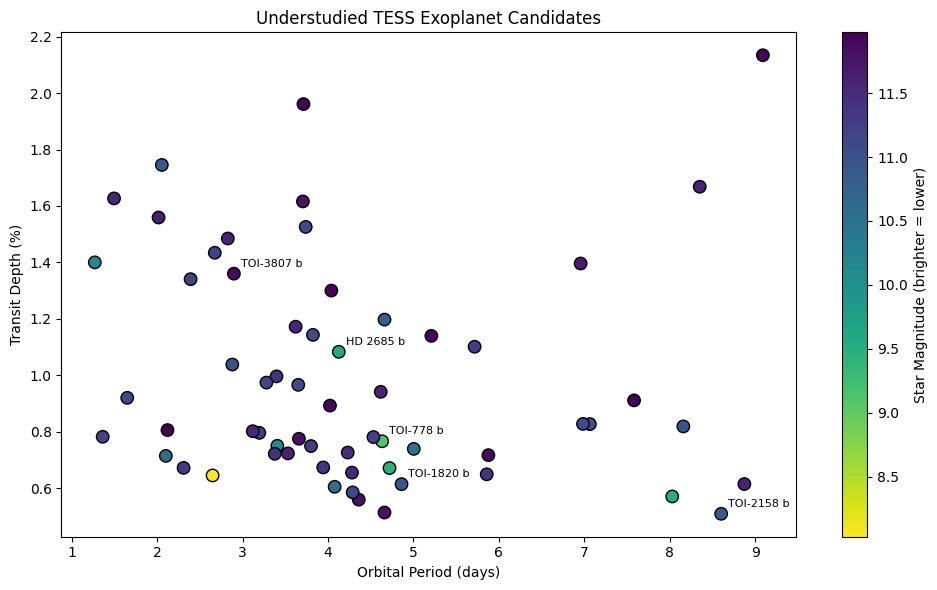


=== TOP 5 RECOMMENDED TARGETS ===
   pl_name  pl_orbper  pl_trandep  sy_vmag  num_references
 HD 2685 b   4.126905      1.0831    9.595               1
TOI-1820 b   4.860673      0.6140   10.899               1
TOI-2158 b   8.600756      0.5090   10.887               1
TOI-3807 b   2.898973      1.3600   11.856               1
 TOI-778 b   4.633616      0.7660    9.109               1


In [9]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = "SELECT pl_name, hostname, pl_orbper, pl_trandep, sy_vmag, pl_refname FROM ps WHERE disc_facility = 'Transiting Exoplanet Survey Satellite (TESS)' AND pl_orbper >= 1 AND pl_orbper <= 10 AND sy_vmag < 12 AND pl_trandep > 0.5"

params = {"QUERY": query, "FORMAT": "csv"}
response = requests.get(url, params=params)

df = pd.read_csv(StringIO(response.text))
print(f"Found {len(df)} rows\n")

# Count references per planet
ref_counts = df.groupby("pl_name")["pl_refname"].count().reset_index()
ref_counts.columns = ["pl_name", "num_references"]

df = df.merge(ref_counts, on="pl_name")
df_unique = df.drop_duplicates("pl_name").sort_values("num_references")

# Filter understudied
understudied = df_unique[df_unique["num_references"] <= 3]
print(f"Understudied candidates (<=3 refs): {len(understudied)}\n")
print(understudied[["pl_name", "pl_orbper", "pl_trandep", "sy_vmag", "num_references"]].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(understudied["pl_orbper"], understudied["pl_trandep"],
                c=understudied["sy_vmag"], cmap="viridis_r", s=80, edgecolors="k")
plt.colorbar(sc, ax=ax, label="Star Magnitude (brighter = lower)")
ax.set_xlabel("Orbital Period (days)")
ax.set_ylabel("Transit Depth (%)")
ax.set_title("Understudied TESS Exoplanet Candidates")
for _, row in understudied.head(5).iterrows():
    ax.annotate(row["pl_name"], (row["pl_orbper"], row["pl_trandep"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.tight_layout()
plt.savefig("../figures/01_candidate_targets.png", dpi=150)
plt.show()

print("\n=== TOP 5 RECOMMENDED TARGETS ===")
print(understudied[["pl_name", "pl_orbper", "pl_trandep", "sy_vmag", "num_references"]].head(5).to_string(index=False))

In [8]:
import os
os.makedirs("../figures", exist_ok=True)
print("figures folder created!")

figures folder created!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
import os

# ── 1. Save the plot as an image first ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(understudied["pl_orbper"], understudied["pl_trandep"],
                c=understudied["sy_vmag"], cmap="viridis_r", s=80, edgecolors="k")
plt.colorbar(sc, ax=ax, label="Star Magnitude (brighter = lower number)")
ax.set_xlabel("Orbital Period (days)")
ax.set_ylabel("Transit Depth (%)")
ax.set_title("Understudied TESS Exoplanet Candidates")
for _, row in understudied.head(5).iterrows():
    ax.annotate(row["pl_name"], (row["pl_orbper"], row["pl_trandep"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.tight_layout()
plot_path = "../figures/01_candidate_targets.png"
plt.savefig(plot_path, dpi=150)
plt.close()

# ── 2. Build the PDF ──────────────────────────────────────────────────────────
pdf_path = "../figures/exoplanet_candidates_report.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=letter)
styles = getSampleStyleSheet()
story = []

# Title
story.append(Paragraph("Exoplanet Transit Research — Candidate Report", styles["Title"]))
story.append(Spacer(1, 12))
story.append(Paragraph("Generated from NASA Exoplanet Archive | TESS Confirmed Planets", styles["Normal"]))
story.append(Spacer(1, 6))
story.append(Paragraph("Filters: Period 1-10 days | Star mag &lt; 12 | Transit depth &gt; 0.5% | References &lt;= 3", styles["Normal"]))
story.append(Spacer(1, 20))

# Plot image
story.append(Paragraph("Candidate Scatter Plot", styles["Heading2"]))
story.append(Spacer(1, 8))
story.append(Image(plot_path, width=480, height=288))
story.append(Spacer(1, 20))

# Table
story.append(Paragraph("Top Candidates (sorted by number of references)", styles["Heading2"]))
story.append(Spacer(1, 8))

table_data = [["Planet", "Period (days)", "Transit Depth (%)", "Star Mag", "# Refs"]]
for _, row in understudied.head(20).iterrows():
    table_data.append([
        row["pl_name"],
        f"{row['pl_orbper']:.2f}",
        f"{row['pl_trandep']:.3f}",
        f"{row['sy_vmag']:.2f}",
        str(int(row["num_references"]))
    ])

t = Table(table_data, colWidths=[140, 90, 110, 80, 60])
t.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#2c3e50")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("FONTSIZE", (0, 0), (-1, -1), 9),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.HexColor("#f2f2f2"), colors.white]),
    ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
    ("ALIGN", (1, 0), (-1, -1), "CENTER"),
]))
story.append(t)
story.append(Spacer(1, 20))

# Recommendation
story.append(Paragraph("Recommendation", styles["Heading2"]))
story.append(Spacer(1, 8))
story.append(Paragraph(
    "HD 2685 b is the top recommended target: only 1 published reference (understudied), "
    "bright host star (mag 9.6), deep transit (1.08%), and an ideal 4.1-day orbital period "
    "giving multiple TESS transits to analyze.",
    styles["Normal"]
))

doc.build(story)
print(f"PDF saved to: {pdf_path}")

ModuleNotFoundError: No module named 'reportlab'

In [11]:
import requests
import pandas as pd
from io import StringIO

url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# Your friends' suggestions (duplicates removed)
friends_planets = [
    "HD 25463 c", "TOI-2267 b", "TOI-1803 b", "TOI-880 c",
    "HD 25295 b", "TIC 147027702 b", "TOI-5292 A b", "TOI-5786 b", "TOI-5108 b"
]

# Build query for these specific planets
planet_list = "', '".join(friends_planets)
query = f"SELECT pl_name, hostname, disc_facility, pl_orbper, pl_trandep, sy_vmag, pl_refname FROM ps WHERE pl_name IN ('{planet_list}')"

params = {"QUERY": query, "FORMAT": "csv"}
response = requests.get(url, params=params)
df = pd.read_csv(StringIO(response.text))

# Count references
ref_counts = df.groupby("pl_name")["pl_refname"].count().reset_index()
ref_counts.columns = ["pl_name", "num_references"]
df = df.merge(ref_counts, on="pl_name").drop_duplicates("pl_name")

# Score each planet against your criteria
def check_planet(row):
    issues = []
    if row["disc_facility"] != "Transiting Exoplanet Survey Satellite (TESS)":
        issues.append(f"❌ Not TESS ({row['disc_facility']})")
    if not (1 <= row["pl_orbper"] <= 10):
        issues.append(f"❌ Period out of range ({row['pl_orbper']:.2f} days)")
    if row["sy_vmag"] >= 12:
        issues.append(f"❌ Star too faint (mag {row['sy_vmag']:.2f})")
    if row["pl_trandep"] <= 0.5:
        issues.append(f"❌ Transit too shallow ({row['pl_trandep']:.3f}%)")
    if row["num_references"] > 3:
        issues.append(f"❌ Too many references ({row['num_references']})")
    return "✅ PASSES ALL" if not issues else "\n   ".join(issues)

df["verdict"] = df.apply(check_planet, axis=1)

# Print results
print("=" * 60)
print("FRIENDS' PLANET RECOMMENDATIONS — VERDICT")
print("=" * 60)

not_found = [p for p in friends_planets if p not in df["pl_name"].values]

for _, row in df.iterrows():
    print(f"\n🪐 {row['pl_name']}")
    print(f"   Period: {row['pl_orbper']:.2f} days | Depth: {row['pl_trandep']:.3f}% | Mag: {row['sy_vmag']:.2f} | Refs: {row['num_references']}")
    print(f"   {row['verdict']}")

if not_found:
    print(f"\n⚠️  NOT FOUND in NASA database: {', '.join(not_found)}")

print("\n" + "=" * 60)
print("SUMMARY — planets that pass all criteria:")
passed = df[df["verdict"] == "✅ PASSES ALL"]
if len(passed) > 0:
    print(passed[["pl_name", "pl_orbper", "pl_trandep", "sy_vmag", "num_references"]].to_string(index=False))
else:
    print("None of the suggestions pass all criteria.")

FRIENDS' PLANET RECOMMENDATIONS — VERDICT

🪐 HD 25463 c
   Period: 3.04 days | Depth: 0.008% | Mag: 6.91 | Refs: 3
   ❌ Transit too shallow (0.008%)

🪐 TOI-5108 b
   Period: 6.75 days | Depth: nan% | Mag: 9.75 | Refs: 2
   ✅ PASSES ALL

🪐 TOI-5786 b
   Period: 12.78 days | Depth: 0.301% | Mag: 10.19 | Refs: 2
   ❌ Period out of range (12.78 days)
   ❌ Transit too shallow (0.301%)

🪐 TOI-1803 b
   Period: 6.29 days | Depth: 0.181% | Mag: 11.87 | Refs: 2
   ❌ Transit too shallow (0.181%)

🪐 TOI-880 c
   Period: 6.39 days | Depth: nan% | Mag: 10.10 | Refs: 2
   ✅ PASSES ALL

🪐 TOI-2267 b
   Period: 2.29 days | Depth: 0.138% | Mag: 15.56 | Refs: 2
   ❌ Star too faint (mag 15.56)
   ❌ Transit too shallow (0.138%)

🪐 TOI-5292 A b
   Period: 2.02 days | Depth: nan% | Mag: 16.42 | Refs: 2
   ❌ Star too faint (mag 16.42)

🪐 TIC 147027702 b
   Period: 44.41 days | Depth: 0.220% | Mag: 11.29 | Refs: 1
   ❌ Period out of range (44.41 days)
   ❌ Transit too shallow (0.220%)

⚠️  NOT FOUND in NASA d